<a href="https://colab.research.google.com/github/Ravi-Teja2111/Shor-s-Algorithm/blob/main/Shors_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qiskit qiskit-aer matplotlib pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.2 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=9fdf5733bfec20c1442fd6995603d9c5329490b67c82a603c1dd5df4ca4d3e5a
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
!pip show qiskit qiskit-aer matplotlib pylatexenc

Name: qiskit
Version: 2.4.1
Summary: An open-source SDK for working with quantum computers at the level of extended quantum circuits, operators, and primitives.
Home-page: https://www.ibm.com/quantum/qiskit
Author: 
Author-email: Qiskit Development Team <qiskit@us.ibm.com>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: dill, numpy, rustworkx, scipy, stevedore, typing-extensions
Required-by: qiskit-aer
---
Name: qiskit-aer
Version: 0.17.2
Summary: Aer - High performance simulators for Qiskit
Home-page: https://github.com/Qiskit/qiskit-aer
Author: AER Development Team
Author-email: qiskit@us.ibm.com
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, psutil, python-dateutil, qiskit, scipy
Required-by: 
---
Name: matplotlib
Version: 3.10.0
Summary: Python plotting package
Home-page: https://matplotlib.org
Author: John D. Hunter, Michael Droettboom
Author-email: Unknown <matplotlib-users@python.org>
License: License agreement for ma

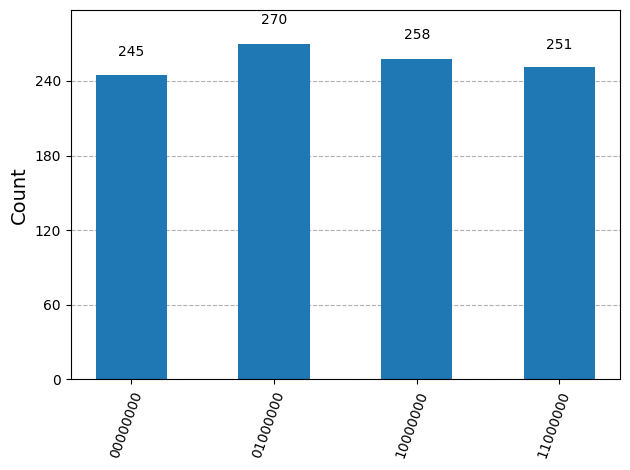

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
from math import gcd

# Function for the controlled-U operator for a=7, N=15
def c_amod15(a, power):
    if a not in [2, 7, 8, 11, 13]:
        raise ValueError("'a' must be 2, 7, 8, 11, or 13")
    U = QuantumCircuit(4)
    for _ in range(power):
        if a in [7, 8]:
            U.swap(0, 1)
            U.swap(1, 2)
            U.swap(2, 3)
            if a == 7:
                for j in range(4): U.x(j)
        if a in [2, 13]:
            U.swap(2, 3)
            U.swap(1, 2)
            U.swap(0, 1)
            if a == 13:
                for j in range(4): U.x(j)
        if a == 11:
            U.swap(0, 2)
            U.swap(1, 3)
            if a == 11:
                for j in range(4): U.x(j)
    U = U.to_gate()
    U.name = f"{a}^{power} mod 15"
    c_U = U.control()
    return c_U

# Inverse QFT function
def qft_dagger(n):
    qc = QuantumCircuit(n)
    for qubit in range(n // 2):
        qc.swap(qubit, n - qubit - 1)
    for j in range(n):
        for m in range(j):
            qc.cp(-np.pi / float(2**(j - m)), m, j)
        qc.h(j)
    qc.name = "QFT†"
    return qc

# Building the circuit
n_count = 8  # Number of counting qubits
qc = QuantumCircuit(n_count + 4, n_count)

# Step 1: Initialize (Psi 1)
for q in range(n_count):
    qc.h(q)
qc.x(3 + n_count) # Register 2 starts at |1>

# Step 2: Modular Exponentiation (Psi 2)
for q in range(n_count):
    qc.append(c_amod15(7, 2**q), [q] + [i + n_count for i in range(4)])

# Step 3: Inverse QFT (Psi 3)
qc.append(qft_dagger(n_count), range(n_count))

# Step 4: Measurement (Psi 4)
qc.measure(range(n_count), range(n_count))

# Execution
simulator = Aer.get_backend('qasm_simulator')
t_qc = transpile(qc, simulator)
counts = simulator.run(t_qc).result().get_counts()
plot_histogram(counts)

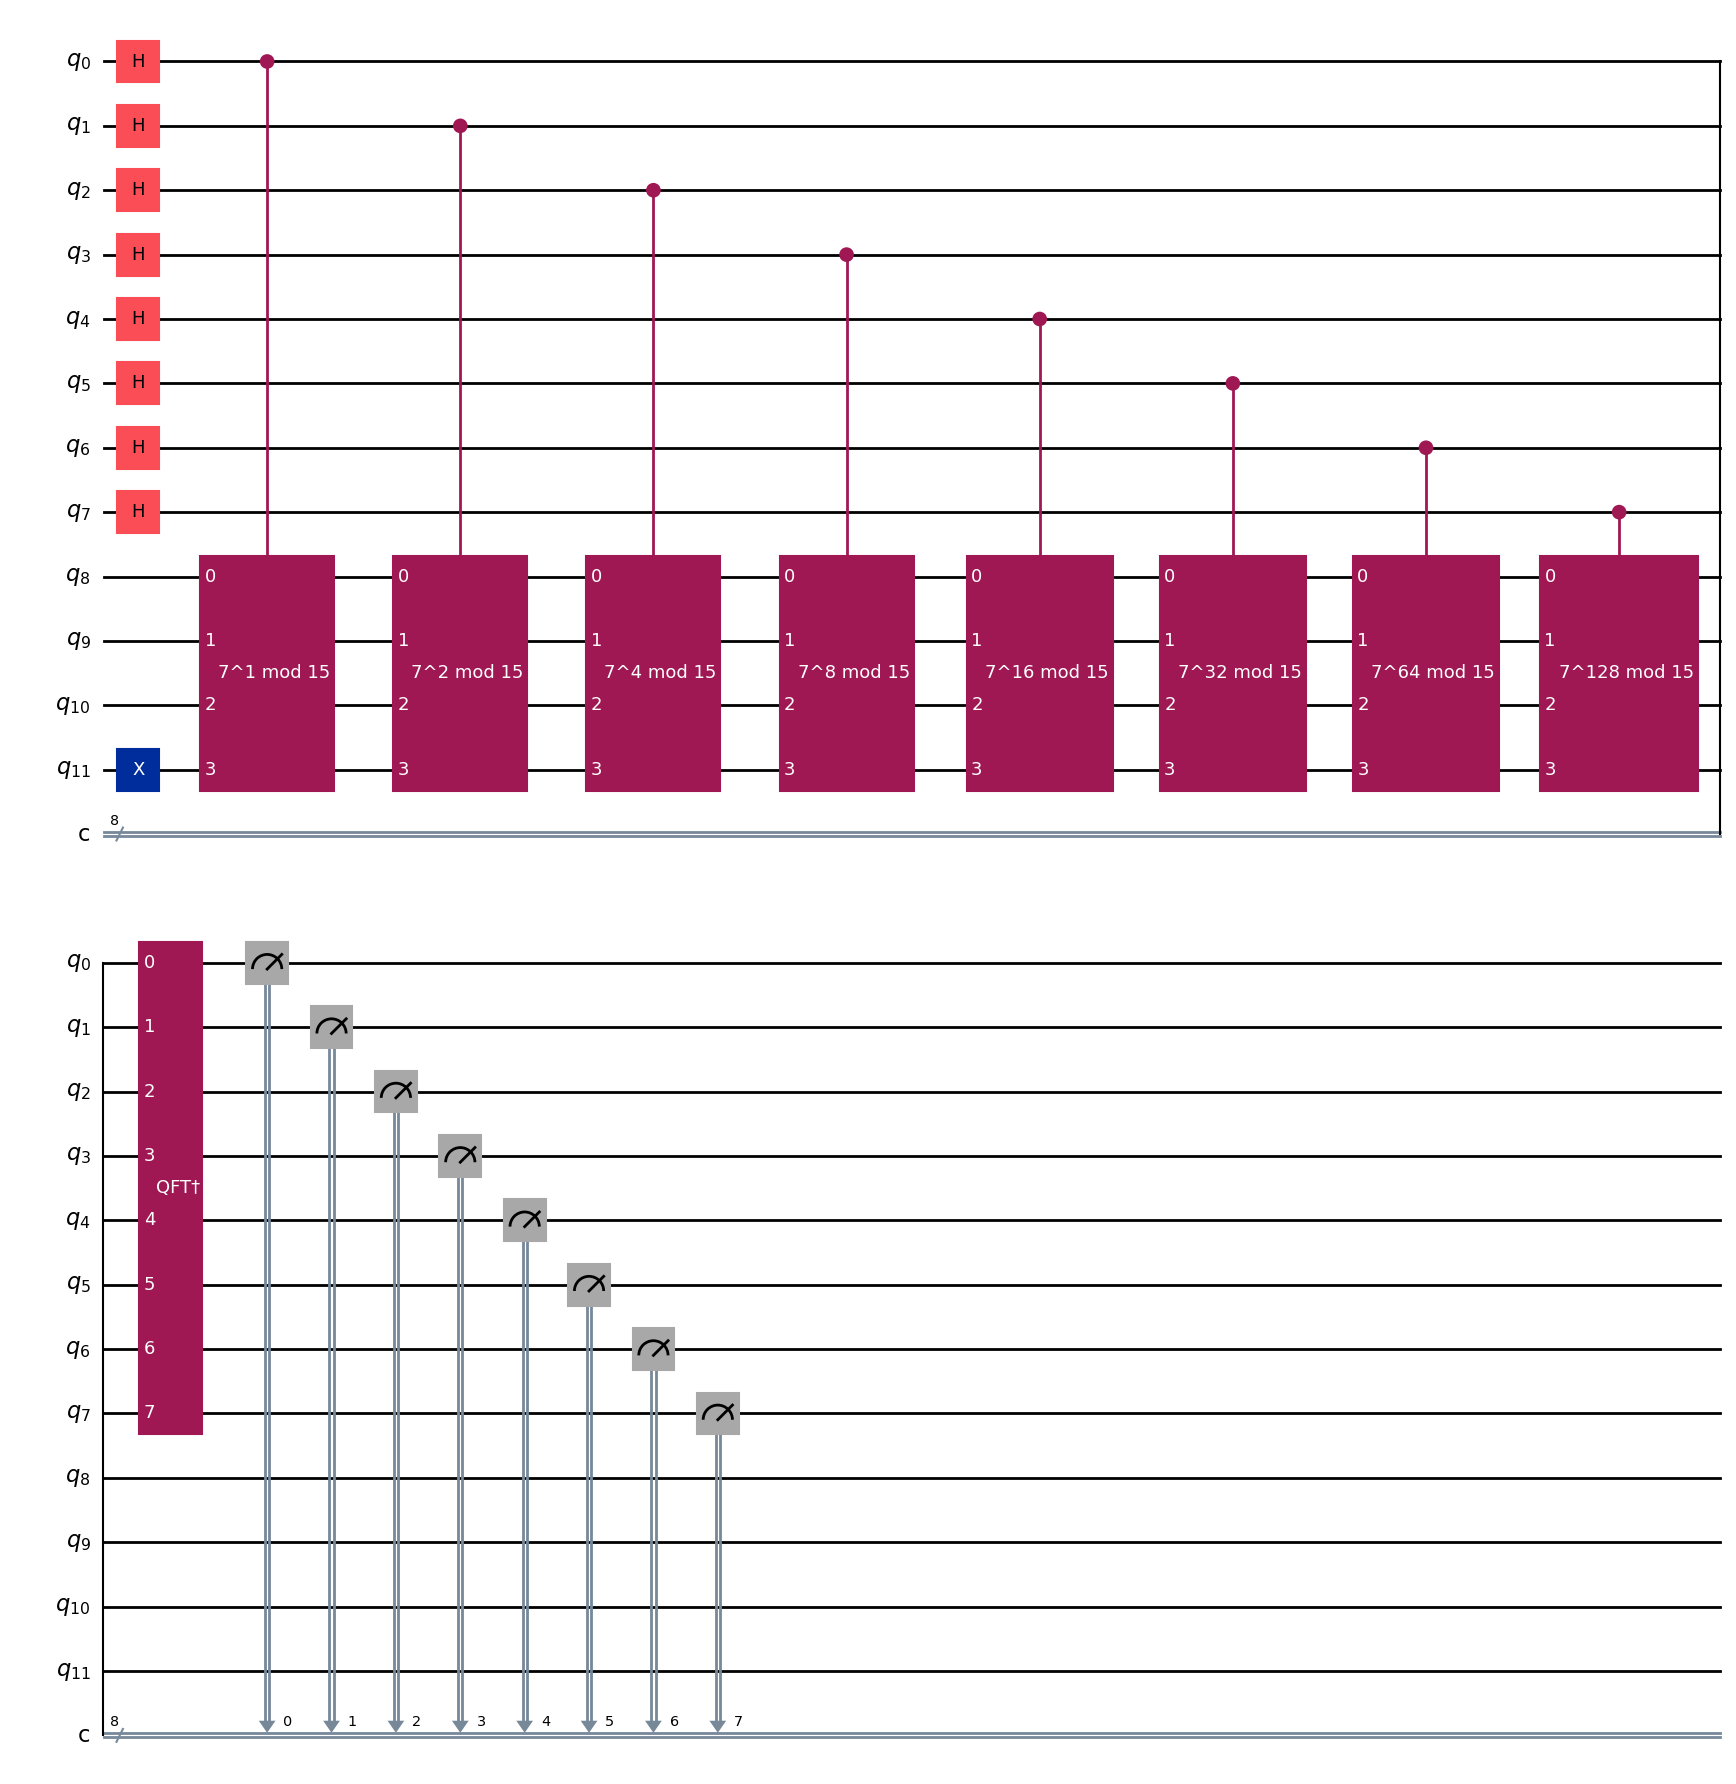

In [ ]:
qc.draw('mpl')